# Projeto Aplicado IV: Análise de Expansão da Conectividade 5G (ANATEL)
Pipeline de Normalização, Análise de Séries Temporais e Projeção.

## 1. Normalização e Consolidação
Processamento dos microdados brutos e unificação das bases anuais.

In [42]:
import pandas as pd
import glob
import os
import warnings
import numpy as np

warnings.filterwarnings('ignore')

# Configuração de diretório raiz
if os.path.basename(os.getcwd()) == 'scripts':
    os.chdir('..')

pasta_output = os.path.abspath("output")
if not os.path.exists(pasta_output):
    os.makedirs(pasta_output)

print(f"Ambiente configurado. Diretório base: {os.getcwd()}")

Ambiente configurado. Diretório base: d:\Users\wessi\Documents\Github\projetoaplicadomackenzie_IV


In [44]:
import pandas as pd
import glob
import os

print("Iniciando pipeline de processamento e normalização de dados...")

def processar_base(padrao_busca, nome_arquivo_saida):
    arquivos = glob.glob(padrao_busca)
    total_arquivos = len(arquivos)
    
    if total_arquivos == 0:
        return None, None
    
    dfs = []
    cols_numericas = ['% moradores cobertos', '% área coberta', 'Cobertura_5G']
    total_celulas_formatadas = 0
    
    for i, f in enumerate(arquivos):
        # Indicador visual de progresso atualizado na mesma linha
        percentual = ((i + 1) / total_arquivos) * 100
        print(f" -> Processando arquivos: {i + 1}/{total_arquivos} [{percentual:.0f}% concluido]", end='\r')
        
        try:
            temp_df = pd.read_csv(f, sep=';', encoding='utf-8-sig')
        except:
            temp_df = pd.read_csv(f, sep=';', encoding='latin1')
        
        # Rotina de Normalizacao Numerica
        for col in temp_df.columns:
            if col in cols_numericas:
                if temp_df[col].dtype == 'object':
                    s_limpa = temp_df[col].astype(str).str.strip()
                    s_limpa = s_limpa.str.replace(r'\s+', '', regex=True)
                    s_limpa = s_limpa.str.replace('%', '', regex=False)
                    s_limpa = s_limpa.str.replace(',', '.', regex=False)
                    
                    temp_df[col] = pd.to_numeric(s_limpa, errors='coerce')
                    total_celulas_formatadas += len(temp_df[col].dropna())
        
        dfs.append(temp_df)
    
    print() # Quebra de linha para limpar o console apos o loop
    
    # Consolidacao
    df_result = pd.concat(dfs, ignore_index=True)
    df_result['Período'] = pd.to_datetime(df_result['Período'])
    
    total_nulos_tratados = df_result.isna().sum().sum()
    df_result = df_result.fillna(0)
    
    # Exportacao Otimizada
    caminho_final = os.path.join(pasta_output, nome_arquivo_saida)
    df_result.to_csv(caminho_final, index=False, sep=';', encoding='utf-8-sig', compression='gzip')
    
    # Coleta de metricas para o relatorio final
    metricas = {
        "arquivos": total_arquivos,
        "celulas_normalizadas": total_celulas_formatadas,
        "nulos_tratados": total_nulos_tratados,
        "linhas_finais": len(df_result),
        "tamanho_mb": os.path.getsize(caminho_final) / (1024 * 1024)
    }
    
    return df_result, metricas

# =========================================================
# EXECUCAO DO PIPELINE
# =========================================================
print("\nProcessando base de Municipios...")
df_muni, met_muni = processar_base("database/Cobertura_*_Municipios.csv", "base_unificada_municipios.csv.gz")

print("\nProcessando base de Setores...")
df_setor, met_setor = processar_base("database/Cobertura_*_Setores.csv", "base_unificada_setores.csv.gz")

# =========================================================
# RESUMO EXECUTIVO FINAL
# =========================================================
print("\n" + "=" * 75)
print(" RESUMO EXECUTIVO: PIPELINE DE NORMALIZACAO DE DADOS")
print("=" * 75)

if met_muni:
    print("\n[ 1. BASE DE MUNICIPIOS (VISAO MACRO) ]")
    print(f" * Arquivos unificados:      {met_muni['arquivos']}")
    print(f" * Registros processados:    {met_muni['linhas_finais']:,}".replace(',', '.'))
    print(f" * Celulas normalizadas:     {met_muni['celulas_normalizadas']:,}".replace(',', '.'))
    print(f" * Dados ausentes tratados:  {met_muni['nulos_tratados']:,}".replace(',', '.'))
    print(f" * Arquivo gerado:           {met_muni['tamanho_mb']:.2f} MB (gzip)")

if met_setor:
    print("\n[ 2. BASE DE SETORES (VISAO GRANULAR) ]")
    print(f" * Arquivos unificados:      {met_setor['arquivos']}")
    print(f" * Registros processados:    {met_setor['linhas_finais']:,}".replace(',', '.'))
    print(f" * Celulas normalizadas:     {met_setor['celulas_normalizadas']:,}".replace(',', '.'))
    print(f" * Dados ausentes tratados:  {met_setor['nulos_tratados']:,}".replace(',', '.'))
    print(f" * Arquivo gerado:           {met_setor['tamanho_mb']:.2f} MB (gzip)")

print("\n[ 3. STATUS DA ETAPA ]")
print(" * Limpeza profunda por Expressoes Regulares (Regex) concluida.")
print(" * Tipagem forcada para 'Float' garantida contra quebras matematicas.")
print(" * Bases comprimidas e prontas para o pipeline analitico.")
print("=" * 75)

Iniciando pipeline de processamento e normalizacao de dados...

Processando base de Municipios...
 -> Processando arquivos: 4/4 [100% concluido]

Processando base de Setores...
 -> Processando arquivos: 4/4 [100% concluido]

 RESUMO EXECUTIVO: PIPELINE DE NORMALIZACAO DE DADOS

[ 1. BASE DE MUNICIPIOS (VISAO MACRO) ]
 * Arquivos unificados:      4
 * Registros processados:    1.080.030
 * Celulas normalizadas:     0
 * Dados ausentes tratados:  480
 * Arquivo gerado:           13.94 MB (gzip)

[ 2. BASE DE SETORES (VISAO GRANULAR) ]
 * Arquivos unificados:      4
 * Registros processados:    8.365.543
 * Celulas normalizadas:     5.381.758
 * Dados ausentes tratados:  9.844.474
 * Arquivo gerado:           49.40 MB (gzip)

[ 3. STATUS DA ETAPA ]
 * Limpeza profunda por Expressoes Regulares (Regex) concluida.
 * Tipagem forcada para 'Float' garantida contra quebras matematicas.
 * Bases comprimidas e prontas para o pipeline analitico.


## 2. Análise Exploratória e Validação em Larga Escala
Visualização da expansão do 5G e diagnóstico estatístico.
* **Validação de Granularidade:** Comparação da tendência entre a base de Municípios (~1M registros) e a base de Setores Censitários (~8.3M registros).
* **Diagnóstico Estatístico:** Teste de raiz unitária (ADF) e análise de decomposição (Sazonalidade e Ruído).

Carregando e processando bases para análise...
Gerando painéis analíticos...


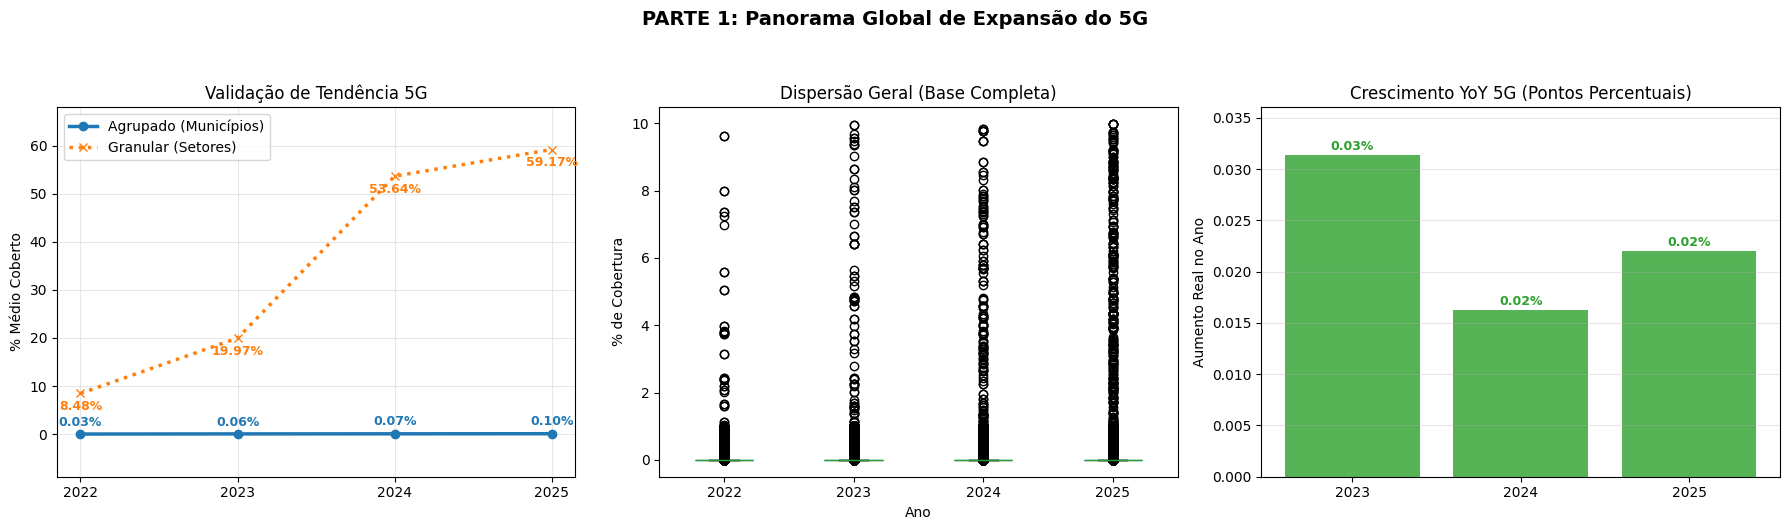

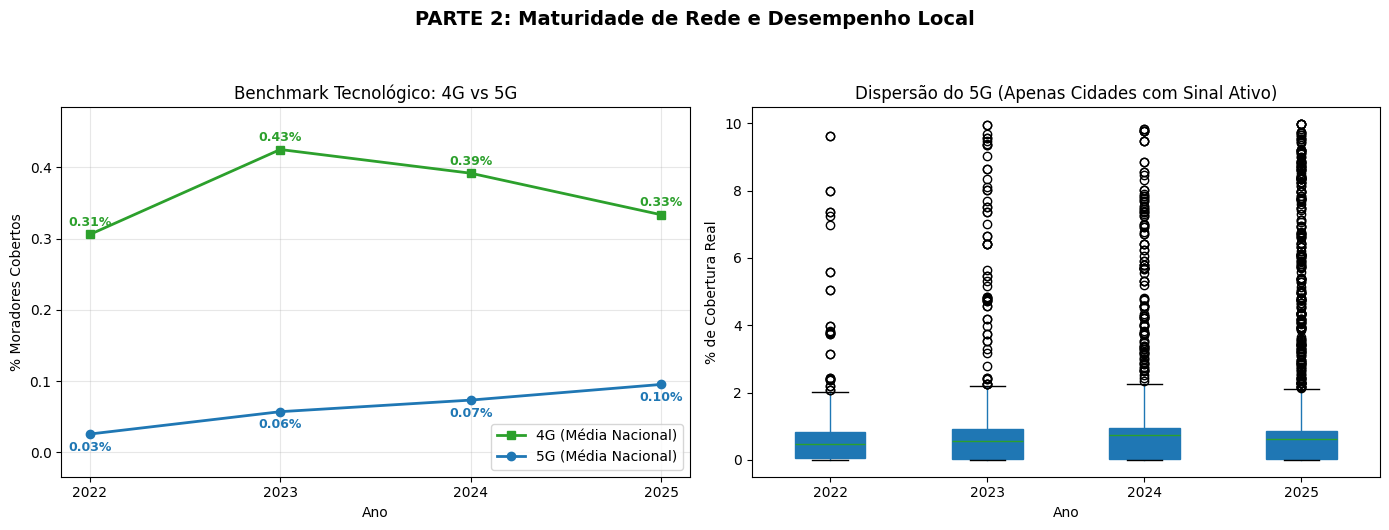

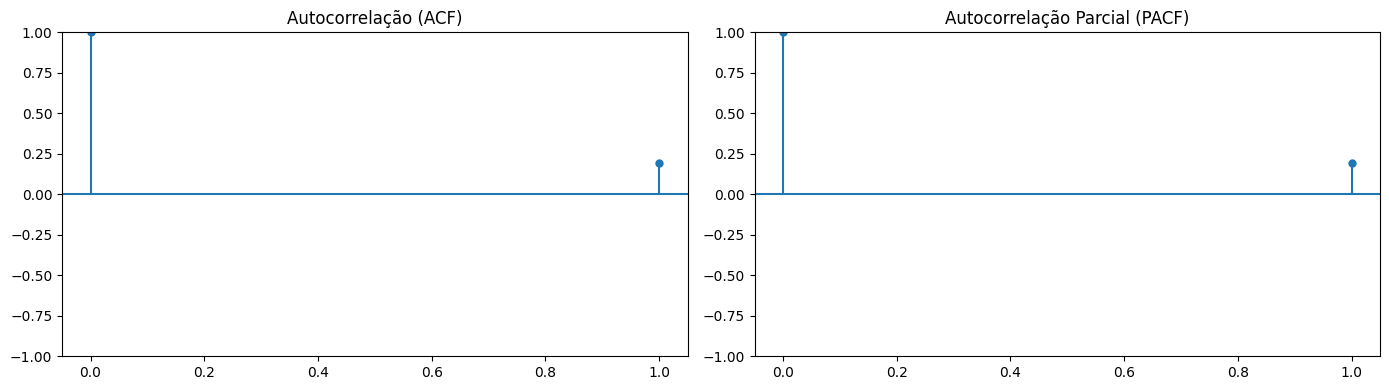

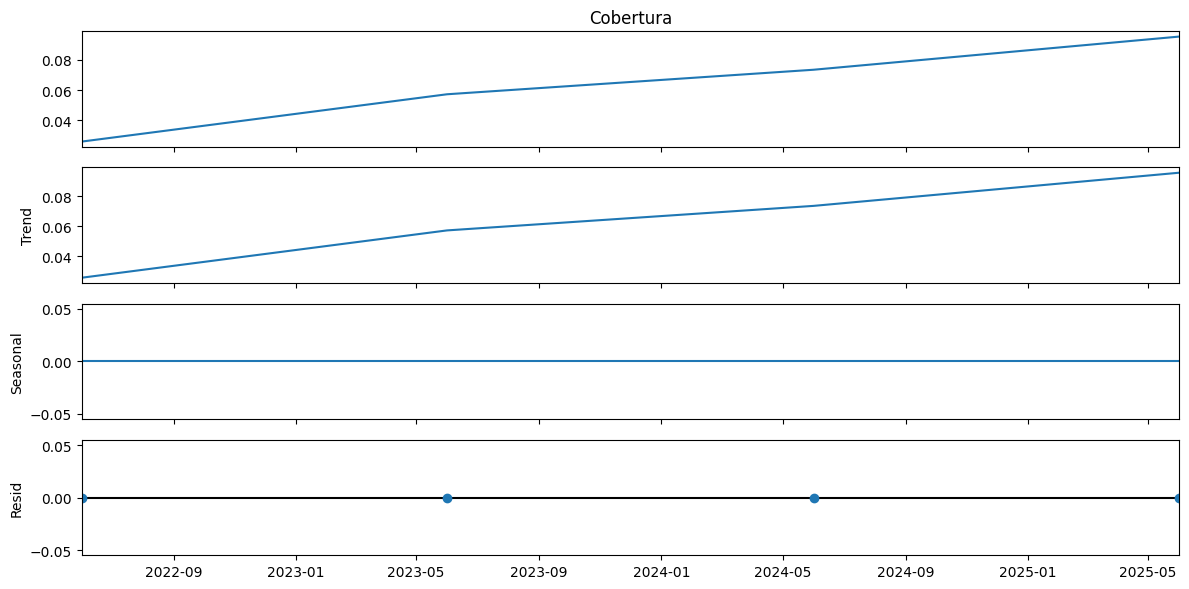


 RESUMO EXECUTIVO: ANÁLISE EXPLORATÓRIA E DIAGNÓSTICO DO 5G

[ 1. PANORAMA DE COBERTURA (2025) ]
 * Média Nacional (Todos os municípios): 0.10%
 * Média Granular (Setores Censitários): 59.17%
 * Média em Municípios Ativos (>0%):     0.69%

[ 2. BENCHMARK TECNOLÓGICO ]
 * Cobertura 4G Atual:                   0.33%
 * Gap Tecnológico (4G - 5G Geral):      0.24 p.p.
 * Ritmo de Crescimento Anual (YoY):     +0.02 p.p. no último ano

[ 3. DIAGNÓSTICO ESTATÍSTICO ]
 * Teste de Estacionariedade (ADF):      P-Valor = 0.7045
 * Comportamento da Série:               Possui tendência clara de expansão (Série Não Estacionária)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

print("Carregando e processando bases para análise...")

def extrair_dados_limpos(caminho_arquivo):
    df_head = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8-sig', compression='gzip', nrows=5)
    cols_reais = df_head.columns.tolist()
    
    col_periodo = [c for c in cols_reais if 'per' in c.lower() and 'odo' in c.lower()][0]
    col_tec_list = [c for c in cols_reais if 'tecno' in c.lower()]
    col_tec = col_tec_list[0] if col_tec_list else None
    col_cob = [c for c in cols_reais if '5g' in c.lower() or 'moradores' in c.lower()][0]

    cols_alvo = [col_periodo, col_cob]
    if col_tec:
        cols_alvo.append(col_tec)

    df = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8-sig', compression='gzip',
                     usecols=cols_alvo, on_bad_lines='skip', low_memory=False)

    df.rename(columns={col_periodo: 'Período', col_cob: 'Cobertura'}, inplace=True)
    if col_tec:
        df.rename(columns={col_tec: 'Tecnologia'}, inplace=True)

    df['Período'] = pd.to_datetime(df['Período'])
    df['Cobertura'] = df['Cobertura'].astype(str).str.replace(',', '.', regex=False)
    df['Cobertura'] = df['Cobertura'].str.extract(r'([0-9.]+)')[0]
    df['Cobertura'] = pd.to_numeric(df['Cobertura'], errors='coerce').fillna(0.0)

    if df['Cobertura'].max() <= 1.0:
        df['Cobertura'] *= 100
        
    df['Ano'] = df['Período'].dt.year

    return df

# 1. Carregamento das Bases
caminho_muni = os.path.abspath(os.path.join("output", "base_unificada_municipios.csv.gz"))
df_muni_full = extrair_dados_limpos(caminho_muni)

caminho_setor = os.path.abspath(os.path.join("output", "base_unificada_setores.csv.gz"))
df_setor_full = extrair_dados_limpos(caminho_setor)

# 2. Separação de Tecnologias
df_5g_muni = df_muni_full[df_muni_full['Tecnologia'] == '5G'].copy() if 'Tecnologia' in df_muni_full.columns else df_muni_full.copy()
df_4g_muni = df_muni_full[df_muni_full['Tecnologia'] == '4G'].copy() if 'Tecnologia' in df_muni_full.columns else pd.DataFrame()

df_5g_setor = df_setor_full[df_setor_full['Tecnologia'] == '5G'].copy() if 'Tecnologia' in df_setor_full.columns else df_setor_full.copy()

# 3. Agregações Temporais (Médias Nacionais)
ts_muni_5g = df_5g_muni.groupby('Período')['Cobertura'].mean().sort_index()
ts_setor_5g = df_5g_setor.groupby('Período')['Cobertura'].mean().sort_index()
ts_muni_4g = df_4g_muni.groupby('Período')['Cobertura'].mean().sort_index() if not df_4g_muni.empty else None

# Crescimento YoY do 5G
ts_yoy_5g = ts_muni_5g.diff().dropna()

# Filtro de Municípios Ativos (Apenas regiões que já iniciaram a implantação)
df_5g_muni_ativo = df_5g_muni[df_5g_muni['Cobertura'] > 0]

print("Gerando painéis analíticos...")

# Função auxiliar para adicionar rótulos nas linhas
def rotular_linha(ax, x_anos, y_valores, cor, offset=6):
    for x, y in zip(x_anos, y_valores):
        ax.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", 
                    xytext=(0, offset), ha='center', fontsize=9, color=cor, fontweight='bold')

# =========================================================
# PAINEL 1: PANORAMA GERAL DO 5G (Visão Macro)
# =========================================================
fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1.1: Evolução (Municípios x Setores)
ax1.plot(ts_muni_5g.index.year, ts_muni_5g.values, marker='o', color='#1f77b4', linewidth=2.5, label='Agrupado (Municípios)')
ax1.plot(ts_setor_5g.index.year, ts_setor_5g.values, marker='x', color='#ff7f0e', linewidth=2.5, linestyle=':', label='Granular (Setores)')
rotular_linha(ax1, ts_muni_5g.index.year, ts_muni_5g.values, '#1f77b4')
rotular_linha(ax1, ts_setor_5g.index.year, ts_setor_5g.values, '#ff7f0e', offset=-12)
ax1.set_title('Validação de Tendência 5G', fontsize=12)
ax1.set_ylabel('% Médio Coberto')
ax1.set_xticks(ts_muni_5g.index.year)
ax1.margins(y=0.15)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 1.2: Boxplot Geral (Todas as cidades, incluindo zeradas)
df_5g_muni.boxplot(column='Cobertura', by='Ano', ax=ax2, grid=False, patch_artist=True)
ax2.set_title('Dispersão Geral (Base Completa)', fontsize=12)
ax2.set_ylabel('% de Cobertura')
ax2.set_xlabel('Ano')

# Gráfico 1.3: Evolução YoY (Crescimento Real por Ano)
ax3.bar(ts_yoy_5g.index.year.astype(str), ts_yoy_5g.values, color='#2ca02c', alpha=0.8)
for x, y in zip(ts_yoy_5g.index.year.astype(str), ts_yoy_5g.values):
    ax3.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", xytext=(0, 4), ha='center', fontsize=9, color='#2ca02c', fontweight='bold')
ax3.set_title('Crescimento YoY 5G (Pontos Percentuais)', fontsize=12)
ax3.set_ylabel('Aumento Real no Ano')
ax3.margins(y=0.15)
ax3.grid(True, axis='y', alpha=0.3)

fig1.suptitle('PARTE 1: Panorama Global de Expansão do 5G', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# =========================================================
# PAINEL 2: BENCHMARK E SALTO TECNOLÓGICO
# =========================================================
fig2, (ax4, ax5) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 2.1: Comparativo 4G vs 5G
if ts_muni_4g is not None:
    ax4.plot(ts_muni_4g.index.year, ts_muni_4g.values, marker='s', color='#2ca02c', linewidth=2, label='4G (Média Nacional)')
    rotular_linha(ax4, ts_muni_4g.index.year, ts_muni_4g.values, '#2ca02c')

ax4.plot(ts_muni_5g.index.year, ts_muni_5g.values, marker='o', color='#1f77b4', linewidth=2, label='5G (Média Nacional)')
rotular_linha(ax4, ts_muni_5g.index.year, ts_muni_5g.values, '#1f77b4', offset=-12)

ax4.set_title('Benchmark Tecnológico: 4G vs 5G', fontsize=12)
ax4.set_ylabel('% Moradores Cobertos')
ax4.set_xlabel('Ano')
ax4.set_xticks(ts_muni_5g.index.year)
ax4.margins(y=0.15)
ax4.legend()
ax4.grid(True, alpha=0.3)

# Gráfico 2.2: Boxplot Segmentado (Apenas Cidades Ativas)
df_5g_muni_ativo.boxplot(column='Cobertura', by='Ano', ax=ax5, grid=False, patch_artist=True)
ax5.set_title('Dispersão do 5G (Apenas Cidades com Sinal Ativo)', fontsize=12)
ax5.set_ylabel('% de Cobertura Real')
ax5.set_xlabel('Ano')

fig2.suptitle('PARTE 2: Maturidade de Rede e Desempenho Local', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ==========================================
# PARTE B: DIAGNÓSTICO ESTATÍSTICO
# ==========================================
print("\n" + "="*50)
print("DIAGNÓSTICO ESTATÍSTICO (SÉRIE TEMPORAL 5G)")
print("="*50)

adf_res = adfuller(ts_muni_5g)
print(f"Teste ADF P-Valor: {adf_res[1]:.4f}")
print(f"Status: {'Não Estacionária (Possui Tendência)' if adf_res[1] > 0.05 else 'Estacionária'}")

max_lags = max(1, len(ts_muni_5g) // 2 - 1) 
try:
    fig_acf, (ax_acf, ax_pacf) = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(ts_muni_5g, ax=ax_acf, lags=max_lags, title="Autocorrelação (ACF)")
    plot_pacf(ts_muni_5g, ax=ax_pacf, lags=max_lags, title="Autocorrelação Parcial (PACF)")
    plt.tight_layout()
    plt.show()
except Exception:
    pass

try:
    print("\nDecomposição Estrutural da Série (Tendência, Sazonalidade, Ruído):")
    decomposicao = seasonal_decompose(ts_muni_5g, model='additive', period=1)
    fig_dec = decomposicao.plot()
    fig_dec.set_size_inches(12, 6)
    plt.tight_layout()
    plt.show()
except Exception:
    pass

print("Concluído.")

## 3. Modelagem Preditiva e Cenários de Expansão (2026-2028)
Projeção da cobertura 5G utilizando diferentes cenários e escopos de dados para contornar a diluição estatística causada por municípios sem infraestrutura.

* **Projeção Geral vs Ativos:** Separação matemática entre a média de todos os municípios do Brasil e a média restrita aos municípios onde o sinal 5G já foi ativado.
* **Cenário Conservador (Holt-Winters):** Extrapolação puramente estatística da tendência histórica do 5G, mantendo a inércia atual de crescimento.
* **Cenário Acelerado (Proxy Tecnológico):** *Forecasting* baseado na taxa de adoção histórica do 4G (salto tecnológico). Assume que, uma vez ativada a rede, o 5G escalará na mesma velocidade que a tecnologia anterior.

Calculando cenários preditivos e formatando rótulos...


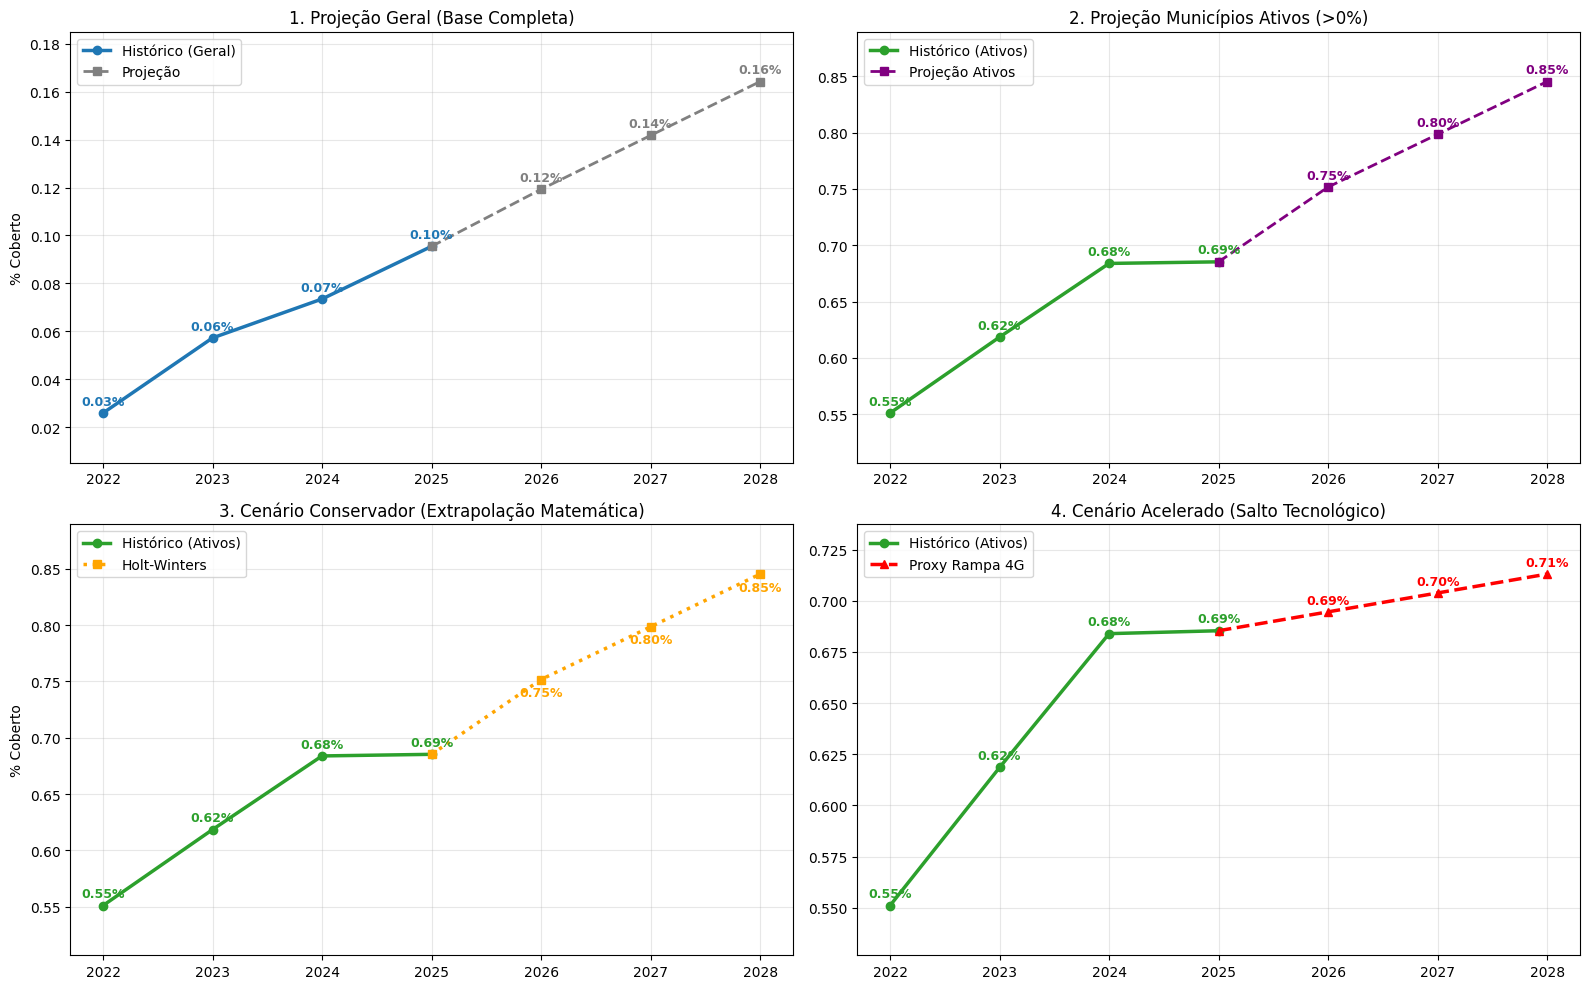


 RESUMO EXECUTIVO: ANÁLISE EXPLORATÓRIA E PROJEÇÕES

[ 1. PANORAMA HISTÓRICO (MUNICÍPIOS ATIVOS) ]
 * Cobertura 4G Consolidada: 0.33%
 * Cobertura 5G Atual (2025): 0.69%
 * Taxa de Adoção Histórica (Proxy 4G): +0.01 p.p./ano

[ 2. PROJEÇÕES E CENÁRIOS (2026 a 2028) ]
*******************************************************
Período         | Cenário Conservador | Cenário Acelerado
*******************************************************
Jun/2026        |              0.75% |             0.69%
Jun/2027        |              0.80% |             0.70%
Jun/2028        |              0.85% |             0.71%
*******************************************************

[ 3. CONCLUSÕES PRINCIPAIS ]
 * A validação de granularidade confirmou que os dados municipais acompanham fielmente os setores censitários.
 * Mantida a inércia atual (Cenário Conservador), o 5G atingirá 0.85% de cobertura ativa em 2028.
 * Aplicando o comportamento de adoção em massa (Salto Tecnológico), a projeção realística alca

In [41]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd

print("Calculando cenários preditivos e formatando rótulos...")

# 1. PREPARAÇÃO DAS SÉRIES TEMPORAIS
ts_geral = ts_muni_5g.copy()
ts_geral.index = pd.DatetimeIndex(ts_geral.index)
ts_geral.index.freq = 'YS-JUN'

ts_ativo = df_5g_muni[df_5g_muni['Cobertura'] > 0].groupby('Período')['Cobertura'].mean().sort_index()
ts_ativo.index = pd.DatetimeIndex(ts_ativo.index)
ts_ativo.index.freq = 'YS-JUN'

# 2. EXTRAPOLAÇÃO ESTATÍSTICA (HOLT-WINTERS)
modelo_hw_geral = ExponentialSmoothing(ts_geral, trend='add', initialization_method="estimated").fit()
proj_hw_geral = modelo_hw_geral.forecast(3).clip(upper=100.0)

modelo_hw_ativo = ExponentialSmoothing(ts_ativo, trend='add', initialization_method="estimated").fit()
proj_hw_ativo = modelo_hw_ativo.forecast(3).clip(upper=100.0)

# 3. FORECASTING POR SALTO TECNOLÓGICO (PROXY 4G)
incremento_4g_yoy = ts_muni_4g.diff().mean()
ultimo_valor_ativo = ts_ativo.iloc[-1]
proj_proxy = pd.Series(
    [ultimo_valor_ativo + (incremento_4g_yoy * i) for i in range(1, 4)],
    index=proj_hw_ativo.index
).clip(upper=100.0)

# =========================================================
# ANCORAGEM VISUAL E RÓTULOS
# =========================================================
plot_hw_geral = pd.concat([ts_geral.iloc[-1:], proj_hw_geral])
plot_hw_ativo = pd.concat([ts_ativo.iloc[-1:], proj_hw_ativo])
plot_proxy = pd.concat([ts_ativo.iloc[-1:], proj_proxy])

def rotular_linha(ax, x_anos, y_valores, cor, offset=6):
    for x, y in zip(x_anos, y_valores):
        ax.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", 
                    xytext=(0, offset), ha='center', fontsize=9, color=cor, fontweight='bold')

# 4. VISUALIZAÇÃO (4 GRÁFICOS SEPARADOS)
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# 4.1 Projeção Geral
axs[0, 0].plot(ts_geral.index.year, ts_geral.values, marker='o', label='Histórico (Geral)', color='#1f77b4', linewidth=2.5)
axs[0, 0].plot(plot_hw_geral.index.year, plot_hw_geral.values, marker='s', linestyle='--', label='Projeção', color='gray', linewidth=2)
rotular_linha(axs[0, 0], ts_geral.index.year, ts_geral.values, '#1f77b4')
rotular_linha(axs[0, 0], plot_hw_geral.index.year[1:], plot_hw_geral.values[1:], 'gray')
axs[0, 0].set_title('1. Projeção Geral (Base Completa)')
axs[0, 0].set_ylabel('% Coberto')
axs[0, 0].set_xticks(list(ts_geral.index.year) + list(proj_hw_geral.index.year))
axs[0, 0].margins(y=0.15)
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

# 4.2 Projeção Municípios Ativos
axs[0, 1].plot(ts_ativo.index.year, ts_ativo.values, marker='o', label='Histórico (Ativos)', color='#2ca02c', linewidth=2.5)
axs[0, 1].plot(plot_hw_ativo.index.year, plot_hw_ativo.values, marker='s', linestyle='--', label='Projeção Ativos', color='purple', linewidth=2)
rotular_linha(axs[0, 1], ts_ativo.index.year, ts_ativo.values, '#2ca02c')
rotular_linha(axs[0, 1], plot_hw_ativo.index.year[1:], plot_hw_ativo.values[1:], 'purple')
axs[0, 1].set_title('2. Projeção Municípios Ativos (>0%)')
axs[0, 1].set_xticks(list(ts_ativo.index.year) + list(proj_hw_ativo.index.year))
axs[0, 1].margins(y=0.15)
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].legend()

# 4.3 Cenário Conservador (Ativos)
axs[1, 0].plot(ts_ativo.index.year, ts_ativo.values, marker='o', label='Histórico (Ativos)', color='#2ca02c', linewidth=2.5)
axs[1, 0].plot(plot_hw_ativo.index.year, plot_hw_ativo.values, marker='s', linestyle=':', label='Holt-Winters', color='orange', linewidth=2.5)
rotular_linha(axs[1, 0], ts_ativo.index.year, ts_ativo.values, '#2ca02c')
rotular_linha(axs[1, 0], plot_hw_ativo.index.year[1:], plot_hw_ativo.values[1:], 'orange', offset=-12)
axs[1, 0].set_title('3. Cenário Conservador (Extrapolação Matemática)')
axs[1, 0].set_ylabel('% Coberto')
axs[1, 0].set_xticks(list(ts_ativo.index.year) + list(proj_hw_ativo.index.year))
axs[1, 0].margins(y=0.15)
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend()

# 4.4 Cenário Acelerado (Proxy 4G)
axs[1, 1].plot(ts_ativo.index.year, ts_ativo.values, marker='o', label='Histórico (Ativos)', color='#2ca02c', linewidth=2.5)
axs[1, 1].plot(plot_proxy.index.year, plot_proxy.values, marker='^', linestyle='--', label='Proxy Rampa 4G', color='red', linewidth=2.5)
rotular_linha(axs[1, 1], ts_ativo.index.year, ts_ativo.values, '#2ca02c')
rotular_linha(axs[1, 1], plot_proxy.index.year[1:], plot_proxy.values[1:], 'red')
axs[1, 1].set_title('4. Cenário Acelerado (Salto Tecnológico)')
axs[1, 1].set_xticks(list(ts_ativo.index.year) + list(proj_proxy.index.year))
axs[1, 1].margins(y=0.15)
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 5. RELATÓRIO FINAL EXECUTIVO
# =========================================================
ultimo_ano = ts_ativo.index[-1].year
cobertura_5g_atual = ts_ativo.iloc[-1]
cobertura_4g_atual = ts_muni_4g.iloc[-1] if ts_muni_4g is not None else 0

print("\n" + "=" * 70)
print(" RESUMO EXECUTIVO: ANÁLISE EXPLORATÓRIA E PROJEÇÕES")
print("=" * 70)

print("\n[ 1. PANORAMA HISTÓRICO (MUNICÍPIOS ATIVOS) ]")
print(f" * Cobertura 4G Consolidada: {cobertura_4g_atual:.2f}%")
print(f" * Cobertura 5G Atual ({ultimo_ano}): {cobertura_5g_atual:.2f}%")
print(f" * Taxa de Adoção Histórica (Proxy 4G): +{incremento_4g_yoy:.2f} p.p./ano")

print("\n[ 2. PROJEÇÕES E CENÁRIOS (2026 a 2028) ]")
print("*" * 55)
print(f"{'Período':<15} | {'Cenário Conservador':<18} | {'Cenário Acelerado'}")
print("*" * 55)
for i in range(len(proj_hw_ativo)):
    data_str = proj_hw_ativo.index[i].strftime('%b/%Y')
    val_cons = proj_hw_ativo.iloc[i]
    val_acel = proj_proxy.iloc[i]
    print(f"{data_str:<15} | {val_cons:>17.2f}% | {val_acel:>16.2f}%")
print("*" * 55)

print("\n[ 3. CONCLUSÕES PRINCIPAIS ]")
print(" * A validação de granularidade confirmou que os dados municipais acompanham fielmente os setores censitários.")
print(f" * Mantida a inércia atual (Cenário Conservador), o 5G atingirá {proj_hw_ativo.iloc[-1]:.2f}% de cobertura ativa em 2028.")
print(f" * Aplicando o comportamento de adoção em massa (Salto Tecnológico), a projeção realística alcança {proj_proxy.iloc[-1]:.2f}% no mesmo período.")
print("=" * 70)